In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

TRAINING IMAGE PREPROCESSING

In [2]:
training_set = tf.keras.utils.image_dataset_from_directory(
    '/Users/ajayyadav/Downloads/eAgro/Dataset/Plant disease/train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)


Found 24047 files belonging to 13 classes.


VALIDATION IMAGE PREPROCESSING

In [3]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    '/Users/ajayyadav/Downloads/eAgro/Dataset/Plant disease/valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)

Found 6011 files belonging to 13 classes.


In [4]:
validation_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 13), dtype=tf.float32, name=None))>

In [5]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[173. 170. 179.]
   [180. 177. 186.]
   [183. 180. 189.]
   ...
   [192. 189. 196.]
   [190. 187. 194.]
   [188. 185. 192.]]

  [[175. 172. 181.]
   [181. 178. 187.]
   [183. 180. 189.]
   ...
   [186. 183. 190.]
   [185. 182. 189.]
   [184. 181. 188.]]

  [[175. 172. 181.]
   [179. 176. 185.]
   [182. 179. 188.]
   ...
   [183. 180. 187.]
   [183. 180. 187.]
   [184. 181. 188.]]

  ...

  [[163. 160. 169.]
   [152. 149. 158.]
   [153. 150. 159.]
   ...
   [148. 142. 152.]
   [149. 143. 155.]
   [153. 147. 159.]]

  [[154. 151. 160.]
   [148. 145. 154.]
   [157. 154. 163.]
   ...
   [150. 144. 156.]
   [151. 145. 157.]
   [154. 148. 160.]]

  [[149. 146. 155.]
   [147. 144. 153.]
   [161. 158. 167.]
   ...
   [146. 140. 152.]
   [146. 140. 152.]
   [149. 143. 155.]]]


 [[[ 84.  84.  84.]
   [ 83.  83.  83.]
   [ 82.  82.  82.]
   ...
   [ 81.  85.  84.]
   [ 80.  84.  83.]
   [ 79.  83.  82.]]

  [[ 82.  82.  82.]
   [ 81.  81.  81.]
   [ 80.  80.  80.]
   ...
   [ 80.  

BUILDING MODEL

In [14]:
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout
from tensorflow.keras.models import Sequential

In [15]:
model = Sequential()

In [16]:
# Bulding Convolutonal Layer and Maxpool layer

model.add(Conv2D(filters = 32, kernel_size = 3, padding = 'same', activation = 'relu', input_shape = [256,256,3]))
model.add(Conv2D(filters = 32, kernel_size = 3, activation = 'relu' ))
model.add(MaxPool2D(pool_size = 2, strides = 2))

/Users/ajayyadav/Downloads/eAgro/eAgro/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.add(Conv2D(filters = 64, kernel_size = 3, padding = 'same', activation = 'relu'))
model.add(Conv2D(filters = 64, kernel_size = 3, activation = 'relu' ))
model.add(MaxPool2D(pool_size = 2, strides = 2))

In [18]:
model.add(Conv2D(filters = 128, kernel_size = 3, padding = 'same', activation = 'relu'))
model.add(Conv2D(filters = 128, kernel_size = 3, activation = 'relu' ))
model.add(MaxPool2D(pool_size = 2, strides = 2))

In [19]:
model.add(Conv2D(filters = 256, kernel_size = 3, padding = 'same', activation = 'relu'))
model.add(Conv2D(filters = 256, kernel_size = 3, activation = 'relu' ))
model.add(MaxPool2D(pool_size = 2, strides = 2))

In [20]:
model.add(Conv2D(filters = 512, kernel_size = 3, padding = 'same', activation = 'relu'))
model.add(Conv2D(filters = 512, kernel_size = 3, activation = 'relu' ))
model.add(MaxPool2D(pool_size = 2, strides = 2))

In [21]:
model.add(Dropout(0.25)) 

In [22]:
# Flattening Operation
model.add(Flatten())

In [23]:
model.add(Dense(units = 1500, activation = 'relu'))

In [24]:
model.add(Dropout(0.4))

In [25]:
# Output Layer
model.add(Dense(units = 13, activation = 'softmax'))

COMPILING MODEL

In [26]:
model.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001), loss='categorical_crossentropy', metrics = ['accuracy'])

In [27]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 254, 254, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 127, 127, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 125, 125, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 62, 62, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 60, 60, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 30, 30, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │    27,649,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 13)             │        19,513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,381,237 (123.52 MB)

 Trainable params: 32,381,237 (123.52 MB)

 Non-trainable params: 0 (0.00 B)

MODEL TRAINING

In [28]:
training_history = model.fit(x = training_set, validation_data=validation_set, epochs=10)

Epoch 1/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 5748s 8s/step - accuracy: 0.6295 - loss: 1.1269 - val_accuracy: 0.8233 - val_loss: 0.5139
Epoch 2/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 3136s 4s/step - accuracy: 0.8559 - loss: 0.4258 - val_accuracy: 0.8932 - val_loss: 0.3060
Epoch 3/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 2950s 4s/step - accuracy: 0.9146 - loss: 0.2527 - val_accuracy: 0.9348 - val_loss: 0.1908
Epoch 4/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 2798s 4s/step - accuracy: 0.9387 - loss: 0.1808 - val_accuracy: 0.9391 - val_loss: 0.1805
Epoch 5/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 2768s 4s/step - accuracy: 0.9537 - loss: 0.1345 - val_accuracy: 0.9369 - val_loss: 0.1867
Epoch 6/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 2790s 4s/step - accuracy: 0.9628 - loss: 0.1095 - val_accuracy: 0.9466 - val_loss: 0.1554
Epoch 7/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 3763s 5s/step - accuracy: 0.9702 - loss: 0.0886 - val_accuracy: 0.9311 - val_loss: 0.2109
Epoch 8/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 6224s 8s/step - accuracy: 0.9718 - loss: 0.0829 - 

MODEL EVALUATION

In [30]:
# Model Evaluation on Training set
train_loss, train_acc = model.evaluate(training_set)

752/752 ━━━━━━━━━━━━━━━━━━━━ 1561s 2s/step - accuracy: 0.9856 - loss: 0.0442


In [31]:
print(train_loss, train_acc)

0.04417536035180092 0.985569953918457


In [32]:
# Model on Validation set
val_loss, val_acc = model.evaluate(validation_set)

188/188 ━━━━━━━━━━━━━━━━━━━━ 344s 2s/step - accuracy: 0.9479 - loss: 0.1648


In [33]:
print(val_loss, val_acc)

0.16475379467010498 0.947928786277771


In [36]:
# Saving Model
# model.save("trained_model.h5")
model.save("trained_model.keras")

In [37]:
training_history.history

{'accuracy': [0.6295171976089478,
  0.8559487462043762,
  0.9145839214324951,
  0.9386618137359619,
  0.9537156224250793,
  0.9628227949142456,
  0.9702249765396118,
  0.9717636108398438,
  0.9793737530708313,
  0.9790826439857483],
 'loss': [1.1269065141677856,
  0.4258219003677368,
  0.2526925206184387,
  0.1807866394519806,
  0.13448132574558258,
  0.10946442186832428,
  0.08855373412370682,
  0.08293396979570389,
  0.06075974926352501,
  0.06021551787853241],
 'val_accuracy': [0.8233239054679871,
  0.8931958079338074,
  0.9347862005233765,
  0.9391116499900818,
  0.9369489550590515,
  0.9465978741645813,
  0.9311262965202332,
  0.9544169306755066,
  0.9595741033554077,
  0.947928786277771],
 'val_loss': [0.5138818621635437,
  0.3059852421283722,
  0.19077464938163757,
  0.18052160739898682,
  0.18671424686908722,
  0.15538468956947327,
  0.21085062623023987,
  0.14123612642288208,
  0.141507089138031,
  0.164753720164299]}

In [39]:
# Recording history in jSON
import json
with open("training_hist.json","w") as f:
    json.dump(training_history.history,f)

In [40]:
training_history.history['accuracy']

[0.6295171976089478,
 0.8559487462043762,
 0.9145839214324951,
 0.9386618137359619,
 0.9537156224250793,
 0.9628227949142456,
 0.9702249765396118,
 0.9717636108398438,
 0.9793737530708313,
 0.9790826439857483]

ACCURACY VISUALISATION

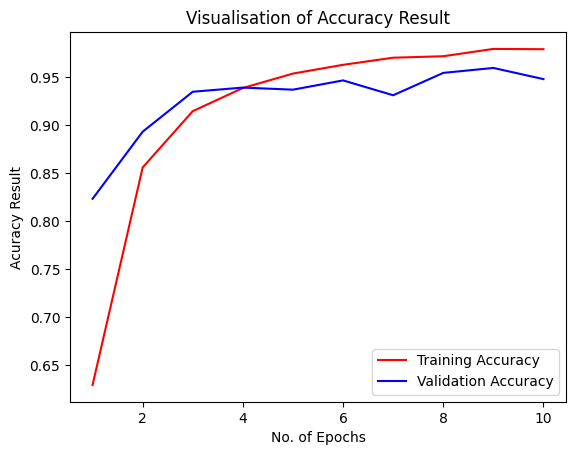

In [44]:
epochs = [i for i in range(1,11)]
plt.plot(epochs, training_history.history['accuracy'], color = 'red', label = 'Training Accuracy')
plt.plot(epochs, training_history.history['val_accuracy'], color = 'blue', label = 'Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.ylabel('Acuracy Result')
plt.title('Visualisation of Accuracy Result')
plt.legend()
plt.show()    

SOME OTHER MATRICS FOR MODEL EVALUATION

In [46]:
class_name = validation_set.class_names
class_name

['Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

In [47]:
test_set = tf.keras.utils.image_dataset_from_directory(
    '/Users/ajayyadav/Downloads/eAgro/Dataset/Plant disease/valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)

Found 6011 files belonging to 13 classes.


In [48]:
y_pred = model.predict(test_set)
y_pred

188/188 ━━━━━━━━━━━━━━━━━━━━ 336s 2s/step


array([[3.5664371e-01, 4.4670533e-06, 1.5556361e-07, ..., 5.5466064e-08,
        1.1683890e-05, 1.2501491e-06],
       [2.3323292e-01, 3.8773988e-03, 1.6033627e-02, ..., 1.4150955e-04,
        1.5149520e-03, 1.4108037e-04],
       [9.9999976e-01, 1.4120769e-12, 2.2366531e-12, ..., 7.3234945e-17,
        4.6802025e-17, 2.3257888e-14],
       ...,
       [2.6148703e-07, 1.3608744e-06, 1.7368167e-05, ..., 2.6222363e-06,
        7.9224028e-06, 9.9763787e-01],
       [3.7678233e-12, 8.1540755e-12, 4.3398898e-09, ..., 4.3177163e-11,
        7.8774955e-12, 9.9999988e-01],
       [2.4207342e-12, 3.2503488e-15, 1.2129115e-11, ..., 8.1687039e-13,
        6.1746358e-11, 9.9995601e-01]], shape=(6011, 13), dtype=float32)

In [49]:
y_pred.shape


(6011, 13)

In [50]:
predicted_categories = tf.argmax(y_pred,axis=1)
predicted_categories

<tf.Tensor: shape=(6011,), dtype=int64, numpy=array([ 0,  4,  0, ..., 12, 12, 12], shape=(6011,))>

In [51]:
true_categories = tf.concat([y for x,y in test_set], axis=0)
true_categories

2026-01-28 23:47:37.814545: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


<tf.Tensor: shape=(6011, 13), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(6011, 13), dtype=float32)>

In [52]:
Y_true = tf.argmax(true_categories,axis=1)
Y_true

<tf.Tensor: shape=(6011,), dtype=int64, numpy=array([ 0,  0,  0, ..., 12, 12, 12], shape=(6011,))>

In [57]:
from sklearn.metrics import classification_report, confusion_matrix

In [55]:
print(classification_report(Y_true, predicted_categories, target_names=class_name))

                                               precision    recall  f1-score   support

                        Potato___Early_blight       1.00      0.93      0.96       485
                         Potato___Late_blight       0.99      0.86      0.92       485
                             Potato___healthy       0.96      1.00      0.98       456
                      Tomato___Bacterial_spot       0.97      0.96      0.96       425
                        Tomato___Early_blight       0.88      0.94      0.91       480
                         Tomato___Late_blight       0.93      0.92      0.92       463
                           Tomato___Leaf_Mold       0.98      0.97      0.97       470
                  Tomato___Septoria_leaf_spot       0.90      0.94      0.92       436
Tomato___Spider_mites Two-spotted_spider_mite       0.96      0.89      0.92       435
                         Tomato___Target_Spot       0.88      0.95      0.91       457
       Tomato___Tomato_Yellow_Leaf_Curl_Vi

In [58]:
cm = confusion_matrix(Y_true, predicted_categories)
cm

array([[452,   2,   0,   0,  10,   3,   5,  13,   0,   0,   0,   0,   0],
       [  1, 415,   5,   2,  23,  22,   1,   9,   1,   4,   2,   0,   0],
       [  0,   0, 455,   0,   0,   0,   0,   0,   0,   1,   0,   0,   0],
       [  0,   0,   1, 407,   3,   0,   0,   1,   0,   6,   7,   0,   0],
       [  0,   0,   1,   4, 451,   5,   0,   7,   3,   8,   1,   0,   0],
       [  0,   1,   0,   4,  21, 425,   0,   4,   0,   2,   4,   1,   1],
       [  0,   0,   0,   0,   2,   1, 455,   8,   2,   0,   0,   2,   0],
       [  0,   0,   3,   3,   4,   3,   4, 409,   1,   7,   0,   2,   0],
       [  0,   0,   3,   0,   0,   0,   0,   1, 387,  25,   2,  17,   0],
       [  0,   0,   4,   0,   0,   0,   0,   3,   6, 435,   0,   7,   2],
       [  0,   0,   0,   0,   0,   0,   0,   1,   3,   0, 486,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 448,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   8,   0,   0, 473]])

CONFUSION MATRIX VISUALISATION

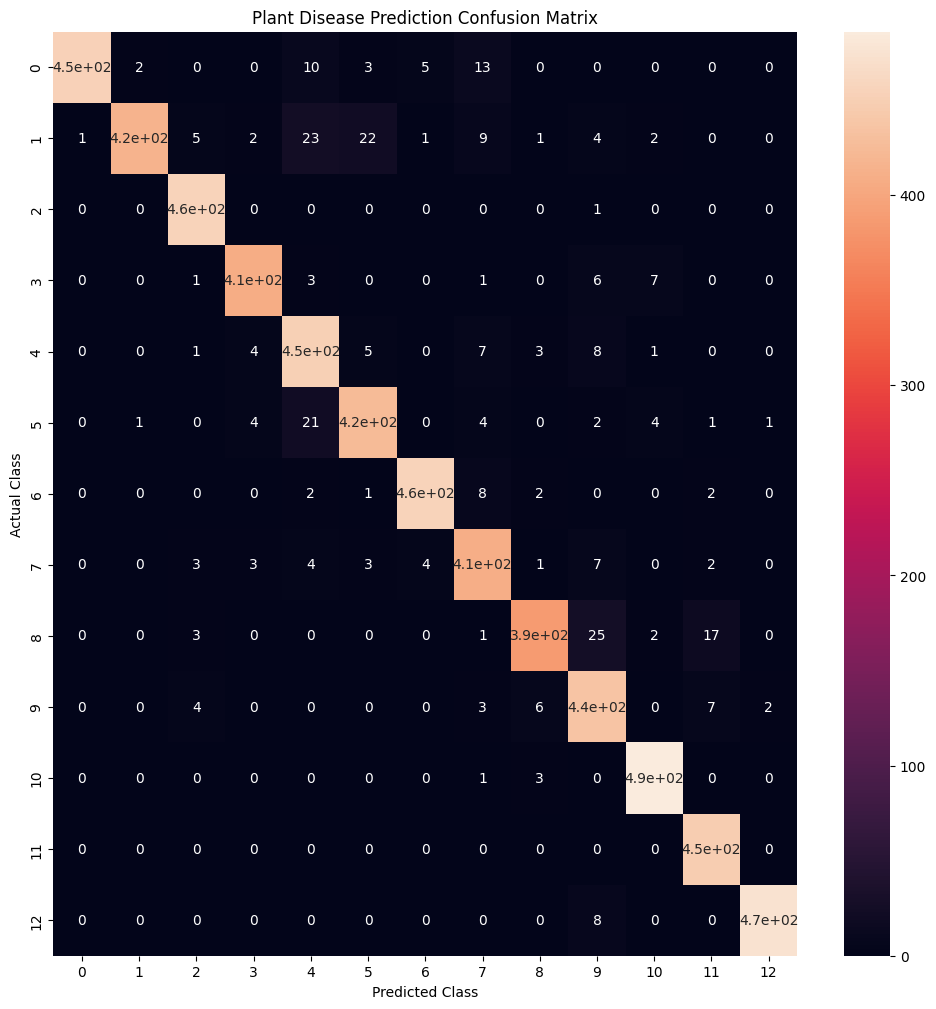

In [68]:
plt.figure(figsize=(12,12))
sns.heatmap(cm, annot=True)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title("Plant Disease Prediction Confusion Matrix")
plt.show()